In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

from src.ingestion.loader import load_processed


In [2]:
events,  frames_exploded, lineups = load_processed("..\..\data\processed")

In [3]:
print(events["type"].iloc[0])
print(type(events["type"].iloc[0]))

{'id': 35, 'name': 'Starting XI'}
<class 'dict'>


In [ ]:
events["type"].apply(lambda x: x.get("name")).head(10)

type
Pass                 177224
Ball Receipt*        168054
Carry                141704
Pressure              47055
Ball Recovery         14396
Duel                  10803
Clearance              6819
Block                  6148
Goal Keeper            4922
Dribble                4549
Foul Committed         4486
Foul Won               4301
Miscontrol             4128
Shot                   4123
Interception           3644
Dispossessed           3494
Dribbled Past          2642
Substitution           1508
Injury Stoppage         957
Half Start              760
Half End                760
50/50                   585
Tactical Shift          539
Referee Ball-Drop       404
Starting XI             332
Shield                  214
Player Off              168
Player On               167
Bad Behaviour           128
Error                    90
Offside                  50
Own Goal Against         24
Own Goal For             24
Name: count, dtype: int64

In [5]:
print(events["id"].iloc[0])
print(type(events["id"].iloc[0]))

59645e89-9c7f-46f2-b662-332c5b8bba12
<class 'str'>


In [11]:
event_id_with_freezeframes = frames_exploded["event_uuid"] 
events["id"].isin(event_id_with_freezeframes)

0         False
1         False
2         False
3         False
4          True
          ...  
615197     True
615198     True
615199     True
615200    False
615201    False
Name: id, Length: 615202, dtype: bool

In [9]:
frames_exploded[frames_exploded["teammate"] == False]["event_uuid"].unique()

<ArrowStringArray>
['5c888f58-fe77-459b-ab3b-a2fa5fb8ab16',
 '776e11e0-9e85-4226-9f9e-edefa3685288',
 'bea4235d-7e40-461c-bb82-6d473f5bb324',
 '84b9b798-0fbe-45bc-a4bf-3621959f29ce',
 '6e2955cf-ad4f-4096-a4dd-053173a3802b',
 'db531534-8bcb-4f84-9958-50db1d8c2131',
 '1615d483-101d-45c1-b554-04cf69897232',
 '39abab21-b9fc-4830-a7c4-f3cf6172df2c',
 '089acaca-894c-4b14-96a5-c845088af8ad',
 'e61c459f-21f7-4c5c-b7f7-da5a6829250b',
 ...
 '4a610ec1-edf3-4066-bd69-cb2a28f2981c',
 '4e0b58f4-24a8-4ddd-b709-d71832480808',
 'c11721ac-1ddd-4a7d-8ee9-6ba005b6380f',
 'e27956d6-67d2-478f-84cf-83a949e3ac98',
 '8eab51fc-0835-4fdb-8fe2-9c38fc38c46b',
 'a2e2b9b3-ee13-4f0d-85dd-d711d081dc7f',
 'c97bde53-d083-4ffc-a545-8636450650e4',
 '07fdd91f-e5eb-499f-9483-261a69dc8acc',
 '9be6bb15-7db5-483e-aee7-44430f07c38f',
 'baa462d6-41ed-4488-a070-ea72380cf419']
Length: 533615, dtype: str

In [12]:
print(events.columns.tolist())

['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'duration', 'tactics', 'match_id', 'related_events', 'player', 'position', 'location', 'pass', 'carry', 'under_pressure', 'out', 'ball_receipt', 'interception', 'off_camera', 'dribble', 'duel', 'counterpress', 'miscontrol', 'shot', 'goalkeeper', 'clearance', 'ball_recovery', 'foul_committed', 'foul_won', 'block', 'substitution', 'injury_stoppage', '50_50', 'bad_behaviour', 'player_off', 'half_start']


In [13]:
print(events["goalkeeper"].iloc[0])
print(events["goalkeeper"].value_counts())

None
goalkeeper
{'body_part': {'id': 35.0, 'name': 'Both Hands'}, 'end_location': None, 'lost_in_play': None, 'outcome': {'id': 15.0, 'name': 'Success'}, 'penalty_saved_to_post': None, 'position': {'id': 44.0, 'name': 'Set'}, 'punched_out': None, 'shot_saved_off_target': None, 'shot_saved_to_post': None, 'success_in_play': None, 'technique': {'id': 46.0, 'name': 'Standing'}, 'type': {'id': 33.0, 'name': 'Shot Saved'}}    277
{'body_part': None, 'end_location': None, 'lost_in_play': None, 'outcome': {'id': 47.0, 'name': 'Claim'}, 'penalty_saved_to_post': None, 'position': None, 'punched_out': None, 'shot_saved_off_target': None, 'shot_saved_to_post': None, 'success_in_play': None, 'technique': None, 'type': {'id': 27.0, 'name': 'Keeper Sweeper'}}                                                                                   221
{'body_part': None, 'end_location': None, 'lost_in_play': None, 'outcome': {'id': 15.0, 'name': 'Success'}, 'penalty_saved_to_post': None, 'position': None, '

In [14]:
events["goalkeeper"].isna()

0         True
1         True
2         True
3         True
4         True
          ... 
615197    True
615198    True
615199    True
615200    True
615201    True
Name: goalkeeper, Length: 615202, dtype: bool

In [15]:
print(events["under_pressure"].value_counts())

under_pressure
True    106938
Name: count, dtype: int64


In [18]:
allowed = ["Pass", "Carry", "Dribble", "Shot"]
event_id_with_freezeframes = frames_exploded["event_uuid"] 

pressing_events = events[
    
    events["type"].apply(lambda x: x.get("name")).isin(allowed) &

    events["id"].isin(event_id_with_freezeframes) &

    events["id"].isin(frames_exploded[frames_exploded["teammate"] == False]["event_uuid"].unique())  &

    events["goalkeeper"].isna() &

    (events["under_pressure"] == True)
]

In [20]:
pressing_events.shape()

TypeError: 'tuple' object is not callable

In [21]:
pressing_events["type"].apply(lambda x: x.get("name")).head(10)

10      Carry
36    Dribble
43      Carry
46      Carry
50      Carry
52       Pass
54      Carry
57      Carry
84      Carry
86       Pass
Name: type, dtype: str

In [22]:
print(len(pressing_events))
print(pressing_events["type"].apply(lambda x: x.get("name")).value_counts())

59719
type
Carry      34442
Pass       20607
Dribble     3761
Shot         909
Name: count, dtype: int64


In [23]:
print(pressing_events["under_pressure"].value_counts())

under_pressure
True    59719
Name: count, dtype: int64


In [24]:
print(pressing_events["location"].iloc[0])

[70.7 75.8]


*EDA*

In [26]:
x_loc = pressing_events["location"].apply(lambda loc: loc[0])
y_loc = pressing_events["location"].apply(lambda loc: loc[1])

In [27]:
x_loc.head()

10    70.7
36    94.5
43    92.6
46    30.1
50    24.4
Name: location, dtype: float64

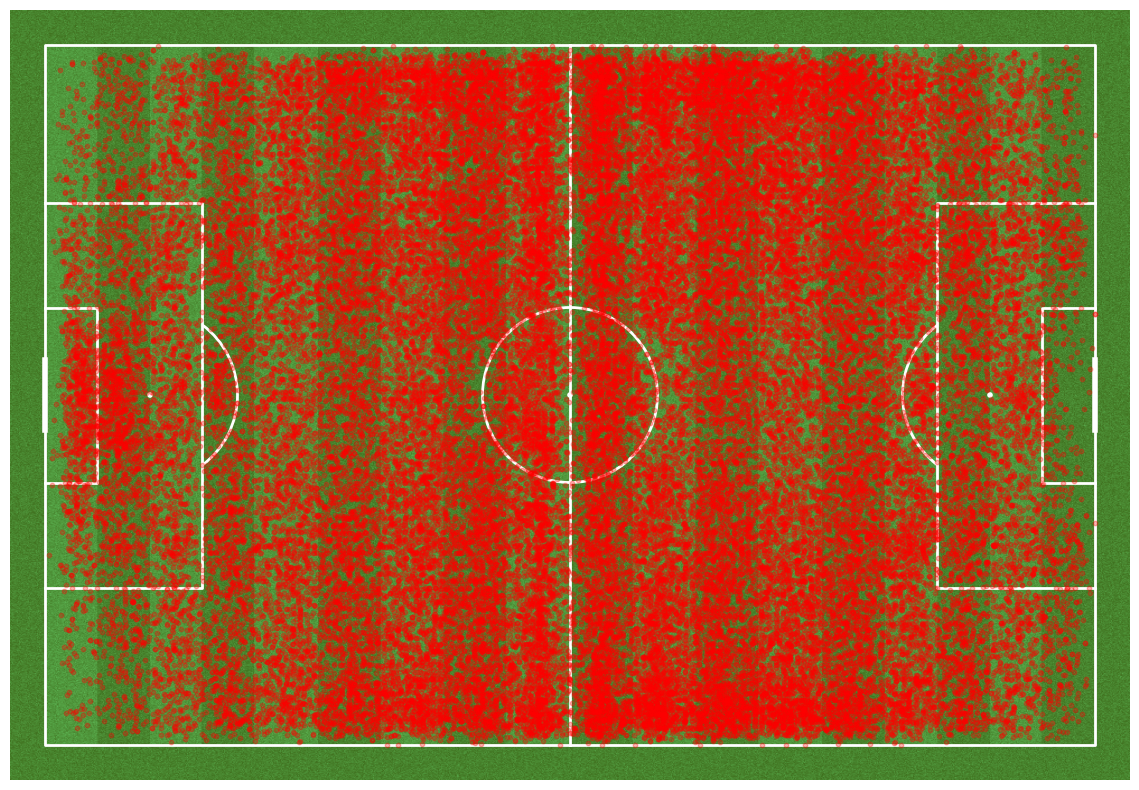

In [29]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
pitch = Pitch(pitch_color='grass', line_color='white', stripe=True,pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(12,8))
pitch.scatter(
    x_loc, 
    y_loc, 
    ax=ax,
    s=10,        # dot size
    alpha=0.3,   # transparency
    color='red'
)
plt.show()

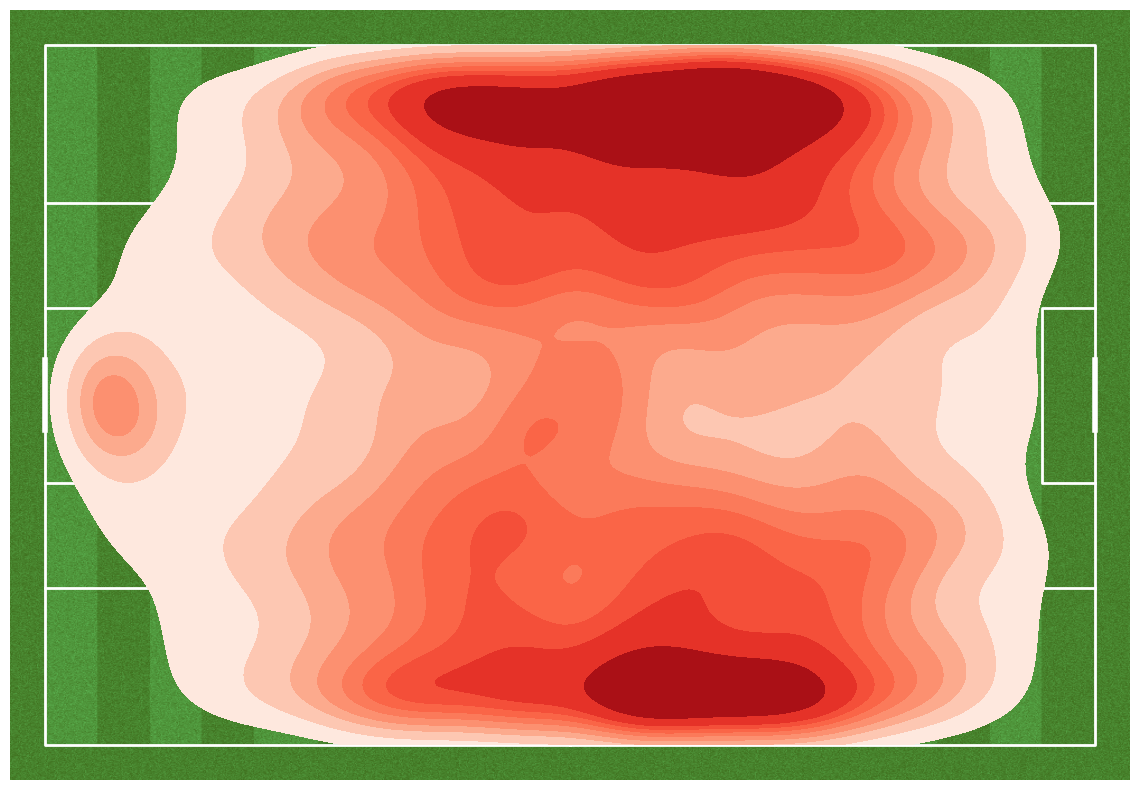

In [33]:
pitch = Pitch(pitch_color='grass', line_color='white', stripe=True,pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.kdeplot(
    x_loc,
    y_loc,
    ax=ax,
    fill=True,
    cmap='Reds'
)

plt.show()

In [34]:
pressing_events[pressing_events["location"].apply(lambda loc: loc[0] < 20)]["type"].apply(lambda x: x.get("name")).value_counts()

type
Carry      2953
Pass       1976
Dribble     103
Name: count, dtype: int64

In [35]:
passes = pressing_events[pressing_events["type"].apply(lambda x: x.get("name")) == "Pass"]
print(passes["pass"].iloc[0])

{'aerial_won': None, 'angle': -1.3954021, 'assisted_shot_id': None, 'body_part': {'id': 40.0, 'name': 'Right Foot'}, 'cross': None, 'cut_back': None, 'deflected': None, 'end_location': array([25.1, 61.2]), 'goal_assist': None, 'height': {'id': 1.0, 'name': 'Ground Pass'}, 'inswinging': None, 'length': 8.023091, 'miscommunication': None, 'no_touch': None, 'outcome': None, 'outswinging': None, 'recipient': {'id': 23558.0, 'name': 'Merih Demiral'}, 'shot_assist': None, 'straight': None, 'switch': None, 'technique': None, 'through_ball': None, 'type': None}


In [36]:
passes[passes["pass"].apply(lambda x: x.get("outcome") if isinstance(x, dict) else None).notna()]["pass"].iloc[0]

{'aerial_won': None,
 'angle': 1.192424,
 'assisted_shot_id': None,
 'body_part': {'id': 40.0, 'name': 'Right Foot'},
 'cross': None,
 'cut_back': None,
 'deflected': None,
 'end_location': array([51. , 79.6]),
 'goal_assist': None,
 'height': {'id': 3.0, 'name': 'High Pass'},
 'inswinging': None,
 'length': 60.90821,
 'miscommunication': None,
 'no_touch': None,
 'outcome': {'id': 75.0, 'name': 'Out'},
 'outswinging': None,
 'recipient': {'id': 10349.0, 'name': 'Mehmet Zeki Çelik'},
 'shot_assist': None,
 'straight': None,
 'switch': True,
 'technique': None,
 'through_ball': None,
 'type': None}

In [46]:
dribbles = pressing_events[pressing_events["type"].apply(lambda x: x.get("name")) == "Dribble"]
print(dribbles["dribble"].iloc[5])

{'no_touch': None, 'nutmeg': None, 'outcome': {'id': 8.0, 'name': 'Complete'}, 'overrun': None}


In [40]:
shots["shot"].apply(lambda x: x.get("outcome", {}).get("name") if isinstance(x, dict) else None).value_counts()

shot
Off T               320
Blocked             244
Saved               180
Goal                 71
Wayward              66
Post                 22
Saved Off Target      4
Saved to Post         2
Name: count, dtype: int64

In [39]:
dribbles["dribble"].apply(lambda x: x.get("outcome", {}).get("name") if isinstance(x, dict) else None).value_counts()

dribble
Complete      2024
Incomplete    1737
Name: count, dtype: int64

In [45]:
carries = pressing_events[pressing_events["type"].apply(lambda x: x.get("name")) == "Carry"]
print(carries["carry"].iloc[56])

{'end_location': array([96.9,  7.5])}


In [52]:
def get_label(row):
    event_type = row["type"].get("name")

    if event_type == "Pass":
        if row["pass"].get("outcome") is None:
            return 1
    elif event_type == "Dribble":
        if (row["dribble"].get("outcome", {}).get("name") == "Complete"):
            return 1
    elif event_type == "Shot":
        if row["shot"].get("outcome",{}).get("name") in ["Goal", "Saved", "Blocked", "Post", "Saved to Post", "Saved Off Target"]:
            return 1
    elif event_type == "Carry":
        if row["carry"].get("end_location")[0] - row["location"][0] >=5:
            return 1



    return 0

In [53]:
pressing_events["label"] = pressing_events.apply(get_label, axis=1)


In [54]:
print(pressing_events["label"].value_counts())

label
0    34545
1    25174
Name: count, dtype: int64


In [55]:
pressing_events.groupby(pressing_events["type"].apply(lambda x: x.get("name")))["label"].mean()

type
Carry      0.220138
Dribble    0.538155
Pass       0.730092
Shot       0.575358
Name: label, dtype: float64

In [56]:
pressing_events["zone"] = pressing_events["location"].apply(lambda loc: 
    "defensive_third" if loc[0] < 40 else 
    "middle_third" if loc[0] < 80 else 
    "final_third"
)

pressing_events.groupby("zone")["label"].mean()

zone
defensive_third    0.413986
final_third        0.393565
middle_third       0.444498
Name: label, dtype: float64